# UTS Prediksi Modern & Machine Learning
## Experiment Challenge: Credit Default Prediction

**Tujuan:** memprediksi apakah nasabah kartu kredit akan *default* (gagal bayar) bulan depan.

**Metrik utama:** F1-score (pendukung: Accuracy, Precision, Recall). **Validasi:** 5-fold Cross Validation.

Alur: Data Understanding → Preparation → Exp 1 (Baseline) → Exp 2 (Preprocessing) → Exp 3 (Perbandingan Model) → Exp 4 (Tuning) → Exp 5 (Advanced Model) → Ringkasan.

In [7]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)

## Experiment 0 — Data Understanding & Preparation
### 0.1 Membaca dataset

In [8]:
df = pd.read_csv('/content/UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### 0.2 Dimensi, tipe data, missing value, dan duplikat

In [9]:
print('Dimensi data     :', df.shape)
print('Missing value    :', df.isna().sum().sum())
print('Duplikat (semua kolom)     :', df.duplicated().sum())
print('Duplikat (tanpa kolom ID)  :', df.drop(columns='ID').duplicated().sum())
df.info()

Dimensi data     : (30000, 25)
Missing value    : 0
Duplikat (semua kolom)     : 0
Duplikat (tanpa kolom ID)  : 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30

### 0.3 Target dan nilai tidak wajar

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64 

default.payment.next.month
0    0.779
1    0.221
Name: proportion, dtype: float64


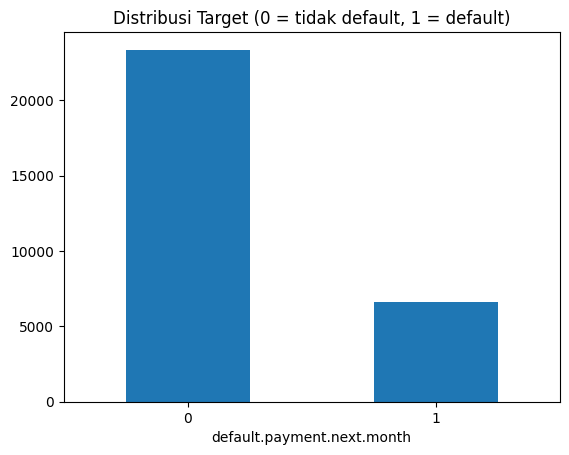

In [10]:
target = 'default.payment.next.month'
print(df[target].value_counts(), '\n')
print(df[target].value_counts(normalize=True).round(3))
df[target].value_counts().plot(kind='bar', title='Distribusi Target (0 = tidak default, 1 = default)', rot=0)
plt.show()

In [11]:
# Kolom kategorikal: bandingkan dengan keterangan dataset
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(col, df[col].value_counts().sort_index().to_dict())
print()
print('PAY_0 :', df['PAY_0'].value_counts().sort_index().to_dict())
print('Tagihan negatif (BILL_AMT1 < 0):', (df['BILL_AMT1'] < 0).sum())

SEX {1: 11888, 2: 18112}
EDUCATION {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE {0: 54, 1: 13659, 2: 15964, 3: 323}

PAY_0 : {-2: 2759, -1: 5686, 0: 14737, 1: 3688, 2: 2667, 3: 322, 4: 76, 5: 26, 6: 11, 7: 9, 8: 19}
Tagihan negatif (BILL_AMT1 < 0): 590


### 0.4 Menentukan predictor & target, lalu train-test split

In [12]:
X = df.drop(columns=['ID', target])   # ID dikeluarkan
y = df[target]

# stratify=y agar proporsi default sama di train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Proporsi default train:', y_train.mean().round(3), '| test:', y_test.mean().round(3))

Train: (24000, 23) | Test: (6000, 23)
Proporsi default train: 0.221 | test: 0.221


Split dilakukan **sebelum** preprocessing apa pun.

### 0.5 Persiapan fungsi evaluasi

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)   # 5-fold CV
hasil = []                                                         # menyimpan semua hasil eksperimen

def evaluasi(exp, nama, model):
    """CV F1 di train set (5-fold), lalu fit di train & evaluasi di test set."""
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1').mean()
    model.fit(X_train, y_train)
    return lapor(exp, nama, model, cv_f1)

def lapor(exp, nama, model, cv_f1):
    pred = model.predict(X_test)
    baris = {'Experiment': exp, 'Model': nama, 'CV F1': cv_f1,
             'Test Accuracy': accuracy_score(y_test, pred),
             'Test Precision': precision_score(y_test, pred),
             'Test Recall': recall_score(y_test, pred),
             'Test F1': f1_score(y_test, pred)}
    hasil.append(baris)
    return pd.DataFrame([baris]).round(4)

## Experiment 1 — Baseline Model
Logistic Regression pada data **mentah** (hanya ID yang dibuang), tanpa scaling/encoding.

In [14]:
baseline = LogisticRegression(max_iter=10000)
evaluasi('1', 'Baseline (Logistic Regression)', baseline)

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1,Baseline (Logistic Regression),0.3689,0.808,0.6866,0.2427,0.3586


**Catatan:** Recall sangat rendah, artinya model hanya menangkap sebagian kecil nasabah yang benar-benar default. Ini menjadi pembanding untuk eksperimen berikutnya.

## Experiment 2 — Preprocessing
Tiga langkah, dicoba bertahap agar terlihat kontribusi masing-masing:
1. **Cleaning** `EDUCATION` & `MARRIAGE` (nilai tidak wajar → "others").
2. **Encoding + Scaling**: One-Hot untuk `SEX`, `EDUCATION`, `MARRIAGE` (karena ini kategori, bukan urutan) dan StandardScaler untuk kolom numerik.
3. **Penanganan imbalance**: `class_weight='balanced'` agar kesalahan pada kelas default (minoritas) lebih "mahal".

In [15]:
def bersihkan(data):
    data = data.copy()
    data['EDUCATION'] = data['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
    data['MARRIAGE']  = data['MARRIAGE'].replace({0: 3})
    return data

# Terapkan cleaning ke train & test (hanya mapping tetap, bukan statistik data -> aman dari leakage)
X_train, X_test = bersihkan(X_train), bersihkan(X_test)

kolom_kat = ['SEX', 'EDUCATION', 'MARRIAGE']
kolom_num = [c for c in X_train.columns if c not in kolom_kat]

preprocessor = ColumnTransformer([
    ('encode', OneHotEncoder(drop='first'), kolom_kat),
    ('scale',  StandardScaler(), kolom_num)])

In [16]:
# Langkah bertahap (hasil ditampilkan untuk perbandingan)
cuplikan = []
for nama, m in [
    ('2a: cleaning saja (tanpa scaling)',          LogisticRegression(max_iter=10000)),
    ('2b: + encoding + scaling',                   make_pipeline(preprocessor, LogisticRegression(max_iter=1000))),
    ('2c: + class_weight balanced',                make_pipeline(preprocessor, LogisticRegression(max_iter=1000, class_weight='balanced')))]:
    cuplikan.append(evaluasi('2', nama, m).assign(Model=nama))
pd.concat(cuplikan, ignore_index=True)

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,2,2a: cleaning saja (tanpa scaling),0.3657,0.8087,0.6941,0.2411,0.3579
1,2,2b: + encoding + scaling,0.3641,0.8088,0.6923,0.2442,0.3610
2,2,2c: + class_weight balanced,0.4812,0.6787,0.3679,0.6307,0.4647


In [17]:
# Bandingkan dengan baseline
hasil_df = pd.DataFrame(hasil)
hasil_df[hasil_df['Experiment'].isin(['1', '2'])].drop(columns='Experiment').round(4)

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Baseline (Logistic Regression),0.3689,0.8080,0.6866,0.2427,0.3586
1,2a: cleaning saja (tanpa scaling),0.3657,0.8087,0.6941,0.2411,0.3579
2,2b: + encoding + scaling,0.3641,0.8088,0.6923,0.2442,0.3610
3,2c: + class_weight balanced,0.4812,0.6787,0.3679,0.6307,0.4647


## Experiment 3 — Model Comparison
Tiga model dibandingkan dengan **preprocessing dan prosedur evaluasi yang sama** (pipeline + 5-fold CV + test set).

In [18]:
model_exp3 = {
    'Logistic Regression': make_pipeline(preprocessor, LogisticRegression(max_iter=1000, class_weight='balanced')),
    'Decision Tree':       make_pipeline(preprocessor, DecisionTreeClassifier(class_weight='balanced', random_state=42)),
    'Random Forest':       make_pipeline(preprocessor, RandomForestClassifier(class_weight='balanced', random_state=42)),
}
exp3 = pd.concat([evaluasi('3', nama, m).assign(Model=nama) for nama, m in model_exp3.items()], ignore_index=True)
exp3.drop(columns='Experiment')

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.4812,0.6787,0.3679,0.6307,0.4647
1,Decision Tree,0.3892,0.7317,0.3940,0.3964,0.3952
2,Random Forest,0.4547,0.8142,0.6536,0.3399,0.4472


In [19]:
terbaik = exp3.loc[exp3['CV F1'].idxmax(), 'Model']      # dipilih dari CV F1 (bukan dari test set)
print('Model terbaik Exp 3 (berdasarkan CV F1):', terbaik)

Model terbaik Exp 3 (berdasarkan CV F1): Logistic Regression


Model terbaik dipilih dari **CV F1** (data training), bukan dari test set, agar test set tetap menjadi ujian akhir yang "jujur". Test set dipakai sebagai pendukung.

## Experiment 4 — Hyperparameter Tuning (GridSearchCV)
Hyperparameter model terbaik dari Exp 3 dituning dengan GridSearchCV, 5-fold CV, scoring F1.

In [20]:
print('Tuning model:', terbaik)
model_terbaik = model_exp3[terbaik]

# Grid untuk Logistic Regression: C = kekuatan regularisasi (kecil = lebih kuat), penalty = jenis regularisasi
param_grid = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l1', 'l2'],
}
# Pakai solver liblinear karena mendukung l1 dan l2
model_terbaik.set_params(logisticregression__solver='liblinear')

grid = GridSearchCV(model_terbaik, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print('Hyperparameter diuji :', param_grid)
print('Kombinasi terbaik    :', grid.best_params_)
print('Best CV F1           :', round(grid.best_score_, 4))

Tuning model: Logistic Regression
Hyperparameter diuji : {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100], 'logisticregression__penalty': ['l1', 'l2']}
Kombinasi terbaik    : {'logisticregression__C': 0.1, 'logisticregression__penalty': 'l1'}
Best CV F1           : 0.4839


In [21]:
# Evaluasi model hasil tuning di test set
lapor('4', f'Tuned {terbaik}', grid.best_estimator_, grid.best_score_)

# Sebelum vs sesudah tuning
pd.DataFrame(hasil).query("Experiment == '4' or (Experiment == '3' and Model == @terbaik)") \
    .assign(Tahap=['Sebelum tuning', 'Setelah tuning']).set_index('Tahap') \
    .drop(columns=['Experiment', 'Model']).round(4)

,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Tahap,,,,,
Sebelum tuning,0.4812,0.6787,0.3679,0.6307,0.4647
Setelah tuning,0.4839,0.6810,0.3702,0.6307,0.4666


**Analisis:** bandingkan kedua baris di atas. Jika selisihnya sangat kecil, artinya hyperparameter default sudah hampir optimal dan tuning hanya memberi peningkatan marginal.

## Experiment 5 — Advanced Model (XGBoost)

In [22]:
rasio = (y_train == 0).sum() / (y_train == 1).sum()

xgb = make_pipeline(preprocessor, XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    scale_pos_weight=rasio, eval_metric='logloss', random_state=42))

evaluasi('5', 'XGBoost', xgb)

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,5,XGBoost,0.5409,0.7642,0.4747,0.6217,0.5383


## Ringkasan Seluruh Eksperimen

In [23]:
semua = pd.DataFrame(hasil)

def ambil(exp, model=None, idx=-1):
    d = semua[semua['Experiment'] == exp]
    if model: d = d[d['Model'] == model]
    return d.iloc[idx]

ringkasan = pd.DataFrame([
    ambil('1').rename('Baseline'),
    ambil('2', idx=-1).rename('Baseline + Preprocessing'),
    ambil('3', terbaik).rename('Model Comparison (terbaik)'),
    ambil('4').rename('Tuned Model'),
    ambil('5').rename('Advanced Model'),
]).drop(columns='Experiment')
ringkasan.index.name = 'Experiment'
ringkasan.round(4)

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment,,,,,,
Baseline,Baseline (Logistic Regression),0.3689,0.8080,0.6866,0.2427,0.3586
Baseline + Preprocessing,2c: + class_weight balanced,0.4812,0.6787,0.3679,0.6307,0.4647
Model Comparison (terbaik),Logistic Regression,0.4812,0.6787,0.3679,0.6307,0.4647
Tuned Model,Tuned Logistic Regression,0.4839,0.6810,0.3702,0.6307,0.4666
Advanced Model,XGBoost,0.5409,0.7642,0.4747,0.6217,0.5383


In [24]:
# Semua model Experiment 3 untuk dilampirkan di laporan
semua[semua['Experiment'] == '3'].drop(columns='Experiment').round(4)

,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
4,Logistic Regression,0.4812,0.6787,0.3679,0.6307,0.4647
5,Decision Tree,0.3892,0.7317,0.3940,0.3964,0.3952
6,Random Forest,0.4547,0.8142,0.6536,0.3399,0.4472


In [25]:
# Model final = F1 CV tertinggi di antara model akhir (Tuned vs Advanced)
kandidat = ringkasan.loc[['Tuned Model', 'Advanced Model']]
final = kandidat['CV F1'].idxmax()
print('Model final (berdasarkan CV F1):', final, '->', kandidat.loc[final, 'Model'])
print(kandidat[['CV F1', 'Test F1']].round(4))

Model final (berdasarkan CV F1): Advanced Model -> XGBoost
                 CV F1  Test F1
Experiment                     
Tuned Model     0.4839   0.4666
Advanced Model  0.5409   0.5383
